In [84]:
## Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
## Import Dataset
df=pd.read_csv(r"C:\Users\-----\Desktop\SkyCity Auckland Restraurant\SkyCity Auckland Restaurants & Bars (1).csv")
df.head()

,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,3.25,458.25,3682.14,1352.45,752.78,2177.19,0.42,0.45,0.25,0.3
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,4.72,1600.08,3605.72,1318.61,731.99,3119.38,0.23,0.45,0.25,0.3
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,3.25,1163.50,7810.95,1555.90,863.42,4172.99,0.44,0.45,0.25,0.3
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,0.89,231.40,2546.02,-72.25,-40.20,2833.26,0.25,0.45,0.25,0.3
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2.66,774.06,3093.09,226.17,125.53,2674.56,0.27,0.45,0.25,0.3


In [56]:
df['CommissionRate']

0       0.28
1       0.28
2       0.30
3       0.33
4       0.33
        ... 
1691    0.30
1692    0.30
1693    0.32
1694    0.28
1695    0.28
Name: CommissionRate, Length: 1696, dtype: float64

In [57]:
# A side-by-side comparison of channel profitability
# All channels net profit totals
InStoreNetProfit_Total=df['InStoreNetProfit'].sum()
UberEatsNetProfit_Total=df['UberEatsNetProfit'].sum().round(2)
DoorDashNetProfit_Total=df['DoorDashNetProfit'].sum()
SelfDeliveryNetProfit_Total=df['SelfDeliveryNetProfit'].sum().round(2)

# Combined all channels net profit overall total
Total_NetProfit=df[['InStoreNetProfit','UberEatsNetProfit','DoorDashNetProfit','SelfDeliveryNetProfit']].sum().sum()

# Calculation of net profit contribution
InStore_Profit_Contribution = (InStoreNetProfit_Total/Total_NetProfit) * 100
DoorDash_Profit_Contribution = (DoorDashNetProfit_Total/Total_NetProfit) * 100
SelfDelivery_Profit_Contribution = (SelfDeliveryNetProfit_Total/Total_NetProfit) * 100
UberEats_Profit_Contribution = (UberEatsNetProfit_Total/Total_NetProfit) * 100

# Print the total profit amount 
print("InStore Net Profit : ",InStoreNetProfit_Total)
print("Uber Eats Net Profit : ",UberEatsNetProfit_Total)
print("Door Dash Net Profit : ",DoorDashNetProfit_Total)
print("Self Delivery Net Profit : ",SelfDeliveryNetProfit_Total)

# Sequence of channels and net profit
net_profitability= pd.DataFrame({ 'Channel': ['In Store','Uber Eats','Door Dash','Self Delivery'],
                                 'Net Profit':[InStoreNetProfit_Total,UberEatsNetProfit_Total,DoorDashNetProfit_Total,SelfDeliveryNetProfit_Total],
                                 'Profit Contribution' : [InStore_Profit_Contribution,DoorDash_Profit_Contribution,
                                                          SelfDelivery_Profit_Contribution,UberEats_Profit_Contribution]
                                })
net_profitability

InStore Net Profit :  3828417.36
Uber Eats Net Profit :  258488.08
Door Dash Net Profit :  151122.25
Self Delivery Net Profit :  3628278.44


,Channel,Net Profit,Profit Contribution
0,In Store,3828417.36,48.668553
1,Uber Eats,258488.08,1.921134
2,Door Dash,151122.25,46.124297
3,Self Delivery,3628278.44,3.286016


In [58]:
df.columns

Index(['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion',
       'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share'],
      dtype='object')

In [59]:
# Understanding of which channels erode margins despite high revenue
margin_calculate=df[['InStoreRevenue','UberEatsRevenue','DoorDashRevenue','SelfDeliveryRevenue','InStoreNetProfit', 'UberEatsNetProfit', 
                     'DoorDashNetProfit','SelfDeliveryNetProfit']].sum()

# Calculate Total Revenue and Net Profit from all 4 channels
total_revenue=df[['InStoreRevenue','UberEatsRevenue','DoorDashRevenue','SelfDeliveryRevenue']].sum().sum()
total_NetProfit=df[['InStoreNetProfit','UberEatsNetProfit','DoorDashNetProfit','SelfDeliveryNetProfit']].sum().sum()

# Calculating channelwise data
result = pd.DataFrame({'Channel' : ['InStore','Uber Eats','Door Dash','Self Delivery'],
                       'Revenue': [
                           margin_calculate['InStoreRevenue'], 
                           margin_calculate['UberEatsRevenue'],
                           margin_calculate['DoorDashRevenue'],
                           margin_calculate['SelfDeliveryRevenue']],
                        'Net Profit':[
                           margin_calculate['InStoreNetProfit'], 
                           margin_calculate['UberEatsNetProfit'],
                           margin_calculate['DoorDashNetProfit'],
                           margin_calculate['SelfDeliveryNetProfit']]})
result['Profit_Margin_%']=((result['Net Profit']/result['Revenue'])*100).round(2)
result['Revenue Contribution']=((result['Revenue']/total_revenue)*100).round(2)
result['Profit Contribution']=((result['Net Profit']/total_NetProfit)*100).round(2)
result

,Channel,Revenue,Net Profit,Profit_Margin_%,Revenue Contribution,Profit Contribution
0,InStore,14284378.07,3828417.36,26.80,18.37,48.67
1,Uber Eats,30816371.49,258488.08,0.84,39.64,3.29
2,Door Dash,16789380.95,151122.25,0.90,21.60,1.92
3,Self Delivery,15849176.29,3628278.44,22.89,20.39,46.12


In [60]:
# Quantify margin erosion due to commissions and delivery costs

df['Commission Amount']=df['UberEatsRevenue']*df['CommissionRate']   # Actual commission amount of Uber Eats
total_commission=df['Commission Amount'].sum().round(2)   # Total commission amount of Uber Eats

delivery_cost=df['SD_DeliveryTotalCost'].sum()   # Total delivery cost

total_revenue=df[['InStoreRevenue','UberEatsRevenue','DoorDashRevenue','SelfDeliveryRevenue']].sum().sum()    # All chanels revenue

# Commission impact
commission_impact = ((total_commission/total_revenue)*100).round(2)
delivery_impact = ((delivery_cost/total_revenue)*100).round(2)

## Print statement
print("Total Commission Amount : ",total_commission)
print("Total Delivery Cost : ",delivery_cost)
print("Commission Impact : ",commission_impact)
print("Delivery Charges Impact : ",delivery_impact)

Total Commission Amount :  9253981.25
Total Delivery Cost :  1281809.47
Commission Impact :  11.9
Delivery Charges Impact :  1.65


In [61]:
# Impack of Commission and Delivery on revenue
erosion_df=pd.DataFrame({ 'Metric':['Commission','Delivery'],
                         'Amount' :[total_commission,delivery_cost],
                         'Impact on Revenue':[commission_impact,delivery_impact]
                        })
erosion_df

,Metric,Amount,Impact on Revenue
0,Commission,9253981.25,11.90
1,Delivery,1281809.47,1.65


In [62]:
# Identify the most cost-efficient channel per restaurant type
channel_group=df.groupby('Segment').sum(numeric_only=True)

# Margin calculations
channel_group['DoorDash_Margin']=(channel_group['DoorDashNetProfit']/channel_group['DoorDashRevenue'])*100
channel_group['InStore_Margin']=(channel_group['InStoreNetProfit']/channel_group['InStoreRevenue'])*100
channel_group['UberEats_Margin']=(channel_group['UberEatsNetProfit']/channel_group['UberEatsRevenue'])*100
channel_group['SelfDelivery_Margin']=(channel_group['SelfDeliveryNetProfit']/channel_group['SelfDeliveryRevenue'])*100

all_combined=channel_group[['DoorDash_Margin','InStore_Margin','UberEats_Margin','SelfDelivery_Margin']].reset_index()
all_combined

,Segment,DoorDash_Margin,InStore_Margin,UberEats_Margin,SelfDelivery_Margin
0,Cafe,6.119366,36.304756,6.091435,28.359178
1,Full-service,-17.458836,12.414319,-17.464645,4.079558
2,Ghost Kitchen,15.123940,45.252319,15.102434,37.018862
3,QSR,5.848353,35.984436,5.847859,28.098293


In [63]:
# Segment average
segment_avg=df.groupby('Segment')[['DoorDashRevenue','InStoreRevenue','UberEatsRevenue','SelfDeliveryRevenue']].mean().round(1)
segment_avg

,DoorDashRevenue,InStoreRevenue,UberEatsRevenue,SelfDeliveryRevenue
Segment,,,,
Cafe,9963.2,8612.3,18268.2,9282.4
Full-service,9768.9,12877.8,18047.4,9283.5
Ghost Kitchen,10110.5,2537.1,18411.4,9706.7
QSR,9872.3,6672.6,18093.4,9323.2


In [64]:
# Compare net profitability across In-Store, Uber Eats, DoorDash, and Self-Delivery
# A side-by-side comparison of channel profitability
# All channels net profit totals
InStoreNetProfit_Total=df['InStoreNetProfit'].sum()
UberEatsNetProfit_Total=df['UberEatsNetProfit'].sum().round(2)
DoorDashNetProfit_Total=df['DoorDashNetProfit'].sum()
SelfDeliveryNetProfit_Total=df['SelfDeliveryNetProfit'].sum().round(2)

# Combined all channels net profit overall total
Total_NetProfit=df[['InStoreNetProfit','UberEatsNetProfit','DoorDashNetProfit','SelfDeliveryNetProfit']].sum().sum().round(2)

# Calculation of net profit contribution
InStore_Profit_Contribution = ((InStoreNetProfit_Total/Total_NetProfit) * 100).round(2)
DoorDash_Profit_Contribution = ((DoorDashNetProfit_Total/Total_NetProfit) * 100).round(2)
SelfDelivery_Profit_Contribution = ((SelfDeliveryNetProfit_Total/Total_NetProfit) * 100).round(2)
UberEats_Profit_Contribution = ((UberEatsNetProfit_Total/Total_NetProfit) * 100).round(2)

# Print the total profit amount 
print("InStore Net Profit : ",InStoreNetProfit_Total)
print("Uber Eats Net Profit : ",UberEatsNetProfit_Total)
print("Door Dash Net Profit : ",DoorDashNetProfit_Total)
print("Self Delivery Net Profit : ",SelfDeliveryNetProfit_Total)

# Sequence of channels and net profit
net_profitability= pd.DataFrame({ 'Channel': ['In Store','Uber Eats','Door Dash','Self Delivery'],
                                 'Net Profit':[InStoreNetProfit_Total,UberEatsNetProfit_Total,DoorDashNetProfit_Total,SelfDeliveryNetProfit_Total],
                                 'Profit Contribution' : [InStore_Profit_Contribution,UberEats_Profit_Contribution,DoorDash_Profit_Contribution,
                                                          SelfDelivery_Profit_Contribution]
                                })
net_profitability

InStore Net Profit :  3828417.36
Uber Eats Net Profit :  258488.08
Door Dash Net Profit :  151122.25
Self Delivery Net Profit :  3628278.44


,Channel,Net Profit,Profit Contribution
0,In Store,3828417.36,48.67
1,Uber Eats,258488.08,3.29
2,Door Dash,151122.25,1.92
3,Self Delivery,3628278.44,46.12


In [65]:
# Support data-driven channel prioritization

Channels= ['InStore','UberEats','DoorDash','SelfDelivery']
# Total orders, revenue and net profit channel wise
InStore_Total=df[['InStoreOrders','InStoreRevenue','InStoreNetProfit']].sum().round()
UberEats_Total=df[['UberEatsOrders','UberEatsRevenue','UberEatsNetProfit']].sum().round()
DoorDash_Total=df[['DoorDashOrders','DoorDashRevenue','DoorDashNetProfit']].sum().round()
SelfDelivery_Total=df[['SelfDeliveryOrders','SelfDeliveryRevenue','SelfDeliveryNetProfit']].sum().round()

# Segment Cost
InStoreCost=InStore_Total['InStoreRevenue']-InStore_Total['InStoreNetProfit']
UberEatsCost=UberEats_Total['UberEatsRevenue']-UberEats_Total['UberEatsNetProfit']
DoorDashCost=DoorDash_Total['DoorDashRevenue']-DoorDash_Total['DoorDashNetProfit']
SelfDeliveryCost=SelfDelivery_Total['SelfDeliveryRevenue']-SelfDelivery_Total['SelfDeliveryNetProfit']

All_total=pd.DataFrame({'Channels': Channels, 
                        'Orders' : [InStore_Total['InStoreOrders'],UberEats_Total['UberEatsOrders'],
                        DoorDash_Total['DoorDashOrders'],SelfDelivery_Total['SelfDeliveryOrders']],
                         'Cost' : [InStoreCost,UberEatsCost,DoorDashCost,SelfDeliveryCost],
                        'Revenue' : [InStore_Total['InStoreRevenue'],UberEats_Total['UberEatsRevenue'],
                        DoorDash_Total['DoorDashRevenue'],SelfDelivery_Total['SelfDeliveryRevenue']],
                        'Net Profit' : [InStore_Total['InStoreNetProfit'],UberEats_Total['UberEatsNetProfit'],
                        DoorDash_Total['DoorDashNetProfit'],SelfDelivery_Total['SelfDeliveryNetProfit']]
                       })
All_total

,Channels,Orders,Cost,Revenue,Net Profit
0,InStore,371391.0,10455961.0,14284378.0,3828417.0
1,UberEats,800353.0,30557883.0,30816371.0,258488.0
2,DoorDash,436135.0,16638259.0,16789381.0,151122.0
3,SelfDelivery,411255.0,12220898.0,15849176.0,3628278.0


In [66]:
df.columns

Index(['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion',
       'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share', 'Commission Amount'],
      dtype='object')

In [67]:
# Highlight self-delivery ROI thresholds
roi_threshold=df.groupby('RestaurantName')[['SelfDeliveryNetProfit','SD_DeliveryTotalCost']].sum().round(2)
roi_threshold.sort_values(by='SelfDeliveryNetProfit', ascending=False)

roi_threshold['SD_ROI']=(roi_threshold['SelfDeliveryNetProfit']/roi_threshold['SD_DeliveryTotalCost']).round(2)

# IF-elif-else statement
def roi_category (x) :
    if x < 0:
        return "Loss"
    elif x < 2:
        return "Low ROI"
    elif x < 4:
        return "Moderate ROI"
    else :
        return "High ROI"

# Apply category to threshold
roi_threshold['ROI_Category_Status']=roi_threshold['SD_ROI'].apply(roi_category)
high_ROI_line=roi_threshold[roi_threshold['ROI_Category_Status']=='High ROI']


sd_netprofit_total=roi_threshold['SelfDeliveryNetProfit'].sum().round(2)
ROI_Contribution_Restraurents=roi_threshold.groupby('ROI_Category_Status')['SelfDeliveryNetProfit'].sum().reset_index()
ROI_Contribution_Restraurents['ROI_Contrinution']=((ROI_Contribution_Restraurents['SelfDeliveryNetProfit']/sd_netprofit_total)*100).round(2)
ROI_Contribution_Restraurents

,ROI_Category_Status,SelfDeliveryNetProfit,ROI_Contrinution
0,High ROI,486554.18,13.41
1,Loss,-361.74,-0.01
2,Low ROI,307584.92,8.48
3,Moderate ROI,2834501.08,78.12


In [68]:
roi_threshold['ROI_Category_Status']=roi_threshold['SD_ROI'].apply(roi_category)
roi_threshold

,SelfDeliveryNetProfit,SD_DeliveryTotalCost,SD_ROI,ROI_Category_Status
RestaurantName,,,,
Bombay Bistro,2703.48,2901.00,0.93,Low ROI
Bombay Cafe,9023.48,4853.72,1.86,Low ROI
Bombay Corner,17519.71,6123.77,2.86,Moderate ROI
Bombay Diner,17766.54,7127.63,2.49,Moderate ROI
Bombay Eatery,15034.71,3133.09,4.80,High ROI
...,...,...,...,...
Urban Pizza Eatery,18125.86,2926.45,6.19,High ROI
Urban Pizza Grill,36584.09,10424.02,3.51,Moderate ROI
Urban Pizza House,30769.79,9788.88,3.14,Moderate ROI


In [83]:
high_ROI_line=roi_threshold[roi_threshold['ROI_Category_Status']=='High ROI']
high_ROI_line.head(10)

,SelfDeliveryNetProfit,SD_DeliveryTotalCost,SD_ROI,ROI_Category_Status
RestaurantName,,,,
Bombay Eatery,15034.71,3133.09,4.80,High ROI
Classic Chicken Dishes Cafe,8821.99,2101.33,4.20,High ROI
Classic Pizza Corner,19736.65,3394.56,5.81,High ROI
Curry Diner,15654.11,3859.88,4.06,High ROI
Dragon Diner,14272.51,3239.95,4.41,High ROI
Dragon Tavern,16667.07,3220.99,5.17,High ROI
Greek Kitchen,5802.29,1104.67,5.25,High ROI
King Burgers Kitchen,12817.47,2622.14,4.89,High ROI
King Pizza Bistro,21708.53,4117.48,5.27,High ROI


In [70]:
# Uber Eats and Door Dash channels revenue
revenue_total=df['UberEatsRevenue'].sum()+df['DoorDashRevenue'].sum().round(2)

# Uber Eats and Door Dash channels orders
orders_total=df['UberEatsOrders'].sum()+df['DoorDashOrders'].sum()

# Uber Eats and Door Dash commissions
uber_commission=(df['UberEatsRevenue']*df['CommissionRate']).sum().round(2)
doordash_commission=(df['DoorDashRevenue']*df['CommissionRate']).sum().round(2)

# Print statements
print("Combined Revenue of UberEats & DoorDash :",revenue_total)
print("Combined Orders of UberEats & DoorDash :",orders_total)
print("Uber Eats Commission Paid :",uber_commission)
print("Door Dash Commission Paid :",doordash_commission)


Combined Revenue of UberEats & DoorDash : 47605752.44
Combined Orders of UberEats & DoorDash : 1236488
Uber Eats Commission Paid : 9253981.25
Door Dash Commission Paid : 5040940.77


In [71]:
df['CommissionRate'].unique()

array([0.28, 0.3 , 0.33, 0.29, 0.31, 0.27, 0.32])

In [72]:
# Commision amount calculations
df['uber_commission']=df['UberEatsRevenue']*df['CommissionRate']
df['doordash_commission']=df['DoorDashRevenue']*df['CommissionRate']

# New Uber Eats ana Door Dash commission calculations
df['new_uber_commission']=df['UberEatsRevenue']*(df['CommissionRate']-0.05)
df['new_doordash_commission']=df['DoorDashRevenue']*(df['CommissionRate']-0.05)
df['Total_Commission']=df['uber_commission']+df['doordash_commission']

#Combined total of commissions
commission_total=(df['uber_commission'].sum()+df['doordash_commission'].sum()).round(2)


CommissionRate_diff=df.groupby('CommissionRate')[['uber_commission','doordash_commission','Total_Commission','new_uber_commission','new_doordash_commission']].sum().round(2)
CommissionRate_diff['Commission_Percent']=((CommissionRate_diff['Total_Commission']/commission_total)*100).round(2)
CommissionRate_diff=CommissionRate_diff.reset_index()
CommissionRate_diff['New Commission Rate']=CommissionRate_diff['CommissionRate'] - 0.05
CommissionRate_diff

,CommissionRate,uber_commission,doordash_commission,Total_Commission,new_uber_commission,new_doordash_commission,Commission_Percent,New Commission Rate
0,0.27,772033.57,423689.03,1195722.59,629064.39,345228.10,8.36,0.22
1,0.28,1415282.21,773521.27,2188803.48,1162553.25,635392.47,15.31,0.23
2,0.29,1259686.48,686514.97,1946201.45,1042499.15,568150.32,13.61,0.24
3,0.30,1508787.80,818668.41,2327456.21,1257323.17,682223.68,16.28,0.25
4,0.31,1768465.83,963494.25,2731960.08,1483229.41,808091.95,19.11,0.26
5,0.32,1676996.86,913713.61,2590710.47,1414966.10,770945.86,18.12,0.27
6,0.33,852728.50,461339.23,1314067.73,723527.21,391439.34,9.19,0.28


In [73]:
# New commission rates
df['New Commission Rates']=df['CommissionRate']-0.05

# Commision amount calculations
df['uber_commission']=df['UberEatsRevenue']*df['CommissionRate']
df['doordash_commission']=df['DoorDashRevenue']*df['CommissionRate']
df['Revised_UberEats_Commission']=(df['UberEatsRevenue']*df['New Commission Rates']).round(2)
df['Revised_DoorDash_Commission']=(df['DoorDashRevenue']*df['New Commission Rates']).round(2)
df['Revised_Commission']=(df['Revised_UberEats_Commission']+df['Revised_DoorDash_Commission']).round(2)

# Old Net profit for UberEats and DoorDash
uber_eats_net_profit=df['UberEatsNetProfit'].sum().round(2)
door_dash_net_profit=df['DoorDashNetProfit'].sum().round(2)
combined_net_profit=uber_eats_net_profit+door_dash_net_profit

# Uber Eats old, revised commissions and difference
ubereats_total_commission=df['uber_commission'].sum().round(2)
ubereats_revised_commission=df['Revised_UberEats_Commission'].sum().round(2)
ubereats_commission_difference=ubereats_total_commission-ubereats_revised_commission

# Door Dash old, revised commissions and difference
doordash_total_commission=df['doordash_commission'].sum().round(2)
doordash_revised_commission=df['Revised_DoorDash_Commission'].sum().round(2)
doordash_commission_difference=(doordash_total_commission-doordash_revised_commission).round(2)

# Difference between old and new revised net profits
uber_eats_revised_net_profit= (uber_eats_net_profit+ubereats_commission_difference).round(2)
door_dash_revised_net_profit= door_dash_net_profit+doordash_commission_difference
total_revised_net_profit=combined_net_profit+ubereats_commission_difference+doordash_commission_difference

# Print Statements
print("Uber Eats Total Commission Paid :",ubereats_total_commission)
print("Uber Eats Revised Commission Should be Paid :",ubereats_revised_commission)
print("Differe Between Old & New Commission is :",(ubereats_commission_difference).round(2))
print("Door Dash Total Commission Paid :",doordash_total_commission)
print("Door Dash Revised Commission Should be Paid :",doordash_revised_commission)
print("Differe Between Old & New Commission is :",doordash_commission_difference)
print("Uber Eats Actual Net Profit :",uber_eats_net_profit)
print("Door Dash Actual Net Profit :",door_dash_net_profit)
print("Uber Eats Net Profit After Revised Commission :",uber_eats_revised_net_profit)
print("Door Dash Net Profit After Revised Commission :",door_dash_revised_net_profit)
print("Total Combined Net Profit Contribution From Both Platforms :",(total_revised_net_profit).round(2))

Uber Eats Total Commission Paid : 9253981.25
Uber Eats Revised Commission Should be Paid : 7713162.77
Differe Between Old & New Commission is : 1540818.48
Door Dash Total Commission Paid : 5040940.77
Door Dash Revised Commission Should be Paid : 4201471.72
Differe Between Old & New Commission is : 839469.05
Uber Eats Actual Net Profit : 258488.08
Door Dash Actual Net Profit : 151122.25
Uber Eats Net Profit After Revised Commission : 1799306.56
Door Dash Net Profit After Revised Commission : 990591.3
Total Combined Net Profit Contribution From Both Platforms : 2789897.86


In [74]:
# New commission rate calculations
df['New Commission Rates']=df['CommissionRate']-0.03

# Old commission rates
df['uber_commission']=df['UberEatsRevenue']*df['CommissionRate']
df['doordash_commission']=df['DoorDashRevenue']*df['CommissionRate']

# Apply new commission rates
df['Revised_UberEats_Commission']=(df['UberEatsRevenue']*df['New Commission Rates']).round(2)
df['Revised_DoorDash_Commission']=(df['DoorDashRevenue']*df['New Commission Rates']).round(2)

# Revised net profit for UberEats and DoorDash
df['UberEats_Revised_Net_Profit']=((df['uber_commission']-df['Revised_UberEats_Commission'])+df['UberEatsNetProfit']).round(2)
df['DoorDash_Revised_Net_Profit']=((df['doordash_commission']-df['Revised_DoorDash_Commission'])+df['DoorDashNetProfit']).round(2)

# Net profit columns
df[['UberEatsNetProfit','UberEats_Revised_Net_Profit','DoorDashNetProfit','DoorDash_Revised_Net_Profit']]

# Channels wise revised net profit calculations
Uber_Eats_Net_Profit=df['UberEats_Revised_Net_Profit'].sum().round(2)
DoorDash_Net_Profit=df['DoorDash_Revised_Net_Profit'].sum().round(2)
In_Store_Net_Profit=df['InStoreNetProfit'].sum().round(2)
Self_Delivery_Net_Profit=df['SelfDeliveryNetProfit'].sum().round(2)

# Overall combine net profit 
Total_NetProfit=(Uber_Eats_Net_Profit+DoorDash_Net_Profit+In_Store_Net_Profit+Self_Delivery_Net_Profit)

# Revised net profit contributions 
Uber_Eats_Net_Profit_Contribution=((Uber_Eats_Net_Profit/Total_NetProfit)*100).round(2)
DoorDash_Net_Profit_Contribution=((DoorDash_Net_Profit/Total_NetProfit)*100).round(2)
In_Store_Net_Profit_Contribution=((In_Store_Net_Profit/Total_NetProfit)*100).round(2)
Self_Delivery_Net_Profit_Contribution=((Self_Delivery_Net_Profit/Total_NetProfit)*100).round(2)

# New revised net profit and contribution
new_net_profit=pd.DataFrame({'Channel': ['InStore','Self Delivery','Uber Eats','Door Dash'],
                             'Net Profit':
                             [In_Store_Net_Profit,Self_Delivery_Net_Profit,Uber_Eats_Net_Profit,DoorDash_Net_Profit
                             ],
                             'Profit Contribution':
                             [In_Store_Net_Profit_Contribution,Self_Delivery_Net_Profit_Contribution,Uber_Eats_Net_Profit_Contribution,DoorDash_Net_Profit_Contribution
                             ]
                            })
new_net_profit       
                                 

,Channel,Net Profit,Profit Contribution
0,InStore,3828417.36,41.19
1,Self Delivery,3628278.44,39.04
2,Uber Eats,1182979.08,12.73
3,Door Dash,654803.68,7.05


In [75]:
# Monthly e-commerce channels orders
monthly_ubereats_orders=df['UberEatsOrders'].sum()
monthly_doordash_orders=df['DoorDashOrders'].sum()

# Monthly e-commerce channels per day orders
Daily_avg_UberEats=(monthly_ubereats_orders/30).round(2)
Daily_avg_DoorDash=(monthly_doordash_orders/30).round(2)

# Print statement
print("Avg Daily Uber Eats Orders:",Daily_avg_UberEats)
print("Avg Daily Door Dash Orders:",Daily_avg_DoorDash)

Avg Daily Uber Eats Orders: 26678.43
Avg Daily Door Dash Orders: 14537.83


In [76]:
# All channels monthly order totals
instore_monthly_orders=df['InStoreOrders'].sum()
selfdelivery_monthly_orders=df['SelfDeliveryOrders'].sum()
ubereats_monthly_orders=df['UberEatsOrders'].sum()
doordash_monthly_orders=df['DoorDashOrders'].sum()

# All channels monthly revenue totals
instore_monthly_revenue=df['InStoreRevenue'].sum()
selfdelivery_monthly_revenue=df['SelfDeliveryRevenue'].sum()
ubereats_monthly_revenue=df['UberEatsRevenue'].sum()
doordash_monthly_revenue=df['DoorDashRevenue'].sum()

# All channels monthly average order value (AOV)
instore_aov=(instore_monthly_revenue/instore_monthly_orders).round(2)
selfdelivery_aov=(selfdelivery_monthly_revenue/selfdelivery_monthly_orders).round(2)
ubereats_aov=(ubereats_monthly_revenue/ubereats_monthly_orders).round(2)
doordash_aov=(doordash_monthly_revenue/doordash_monthly_orders).round(2)

# Arrange in proper sequence
avg_order_value=pd.DataFrame({'Channel' :['In-Store','Self Delivery','Uber Eats','Door Dash'],
                              'AVg Order Value':[instore_aov,selfdelivery_aov,ubereats_aov,doordash_aov]
                             })
avg_order_value

,Channel,AVg Order Value
0,In-Store,38.46
1,Self Delivery,38.54
2,Uber Eats,38.50
3,Door Dash,38.50


In [77]:
# Find outliers
def detect_outliers_iqr (df, column ):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=(Q1-1.5*IQR).round(2)
    upper=(Q3+1.5*IQR).round(2)
    outliers=df[(df[column]<lower) | (df[column]>upper)]
    return outliers, lower, upper
aov_outliers, aov_low, aov_high = detect_outliers_iqr(df, 'SelfDeliveryOrders')

# Print statement
print("AOV Outliers:", aov_outliers)
print("Lower Bound:", aov_low)
print("Upper Bound:", aov_high)

AOV Outliers:      CuisineType  RestaurantID        RestaurantName       Segment  \
1364       Pizza         25449     King Pizza Tavern          Cafe   
1369       Pizza         25392    Urban Pizza Corner           QSR   
1371       Pizza         25025       Top Pizza Grill  Full-service   
1375       Pizza         25369    Lucky Pizza Bistro          Cafe   
1376       Pizza         26111   Urban Pizza Kitchen           QSR   
...          ...           ...                   ...           ...   
1566       Pizza         25423  Classic Pizza Corner          Cafe   
1567       Pizza         26524    Lucky Pizza Bistro          Cafe   
1570       Pizza         25304  Classic Pizza Bistro  Full-service   
1571       Pizza         26450      Top Pizza Bistro           QSR   
1573       Pizza         26651     Urban Pizza Grill           QSR   

           Subregion  GrowthFactor    AOV  MonthlyOrders  InStoreOrders  \
1364             CBD          0.99  33.24           1773            46

In [78]:
# Correlation
num_df=df.select_dtypes(include=['number'])
corr_metric=num_df.corr().round(2)
corr_metric

,RestaurantID,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,...,doordash_commission,new_uber_commission,new_doordash_commission,Total_Commission,New Commission Rates,Revised_UberEats_Commission,Revised_DoorDash_Commission,Revised_Commission,UberEats_Revised_Net_Profit,DoorDash_Revised_Net_Profit
RestaurantID,1.00,-0.00,-0.01,0.02,0.02,0.02,0.01,0.02,0.01,0.01,...,0.01,-0.00,0.01,0.00,-0.04,-0.00,0.01,0.00,-0.02,-0.02
GrowthFactor,-0.00,1.00,0.21,0.04,0.02,0.06,0.04,0.03,0.04,0.11,...,0.09,0.10,0.09,0.10,-0.03,0.10,0.09,0.10,0.03,0.03
AOV,-0.01,0.21,1.00,-0.01,-0.02,0.15,-0.01,-0.01,0.01,0.29,...,0.28,0.28,0.28,0.29,-0.05,0.28,0.28,0.28,0.10,0.10
MonthlyOrders,0.02,0.04,-0.01,1.00,0.74,0.72,0.83,0.82,0.72,0.79,...,0.76,0.77,0.76,0.78,0.01,0.77,0.76,0.77,-0.09,-0.09
InStoreOrders,0.02,0.02,-0.02,0.74,1.00,0.98,0.34,0.28,0.58,0.32,...,0.25,0.31,0.25,0.29,-0.02,0.31,0.25,0.29,-0.46,-0.47
InStoreRevenue,0.02,0.06,0.15,0.72,0.98,1.00,0.34,0.27,0.57,0.37,...,0.30,0.35,0.29,0.34,-0.03,0.35,0.29,0.33,-0.44,-0.44
UberEatsOrders,0.01,0.04,-0.01,0.83,0.34,0.34,1.00,0.95,0.31,0.95,...,0.89,0.93,0.89,0.93,0.02,0.93,0.89,0.93,0.09,0.09
DoorDashOrders,0.02,0.03,-0.01,0.82,0.28,0.27,0.95,1.00,0.36,0.90,...,0.93,0.88,0.93,0.91,0.01,0.89,0.93,0.91,0.10,0.10
SelfDeliveryOrders,0.01,0.04,0.01,0.72,0.58,0.57,0.31,0.36,1.00,0.30,...,0.35,0.29,0.34,0.31,0.02,0.29,0.35,0.31,0.05,0.06
UberEatsRevenue,0.01,0.11,0.29,0.79,0.32,0.37,0.95,0.90,0.30,1.00,...,0.94,0.98,0.94,0.98,0.00,0.98,0.94,0.98,0.12,0.12


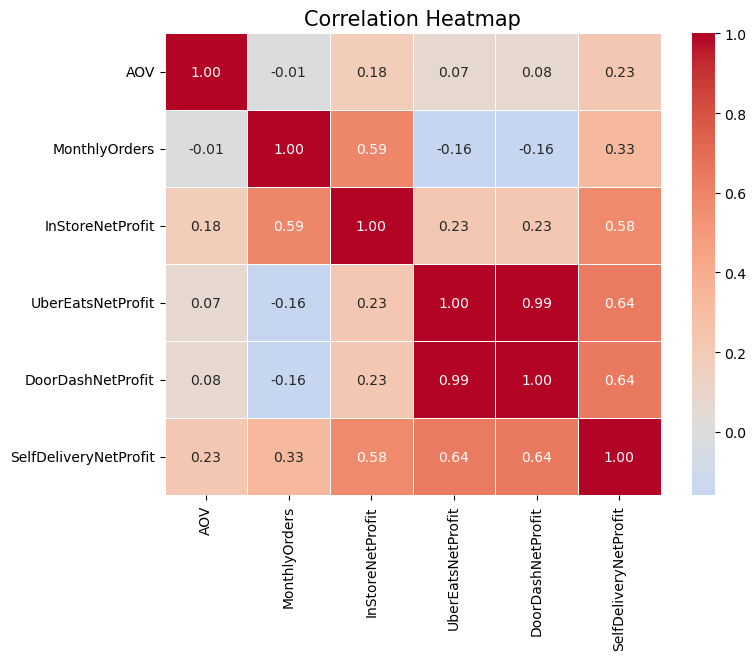

In [97]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_colmn, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

In [96]:
# Correlation 
colmn=[ 'AOV', 'MonthlyOrders','InStoreNetProfit','UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit',]
corr_matrix_colmn=df[colmn].corr()
corr_matrix_colmn.round(2)

,AOV,MonthlyOrders,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit
AOV,1.00,-0.01,0.18,0.07,0.08,0.23
MonthlyOrders,-0.01,1.00,0.59,-0.16,-0.16,0.33
InStoreNetProfit,0.18,0.59,1.00,0.23,0.23,0.58
UberEatsNetProfit,0.07,-0.16,0.23,1.00,0.99,0.64
DoorDashNetProfit,0.08,-0.16,0.23,0.99,1.00,0.64
SelfDeliveryNetProfit,0.23,0.33,0.58,0.64,0.64,1.00


In [92]:
# Correlation 
colmn=[ 'AOV', 'MonthlyOrders','InStoreRevenue','UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue',]
corr_matrix_colmn=df[colmn].corr()
corr_matrix_colmn.round(2)

,AOV,MonthlyOrders,InStoreRevenue,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue
AOV,1.00,-0.01,0.15,0.29,0.29,0.22
MonthlyOrders,-0.01,1.00,0.72,0.79,0.77,0.69
InStoreRevenue,0.15,0.72,1.00,0.37,0.31,0.59
UberEatsRevenue,0.29,0.79,0.37,1.00,0.96,0.35
DoorDashRevenue,0.29,0.77,0.31,0.96,1.00,0.40
SelfDeliveryRevenue,0.22,0.69,0.59,0.35,0.40,1.00


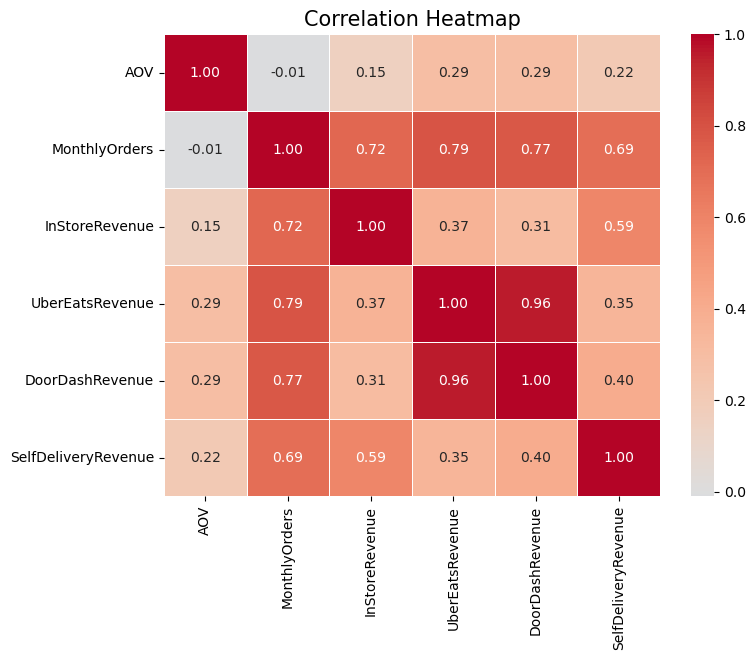

In [94]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_colmn, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

In [80]:
df.columns

Index(['CuisineType', 'RestaurantID', 'RestaurantName', 'Segment', 'Subregion',
       'GrowthFactor', 'AOV', 'MonthlyOrders', 'InStoreOrders',
       'InStoreRevenue', 'UberEatsOrders', 'DoorDashOrders',
       'SelfDeliveryOrders', 'UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue', 'COGSRate', 'OPEXRate', 'CommissionRate',
       'DeliveryRadiusKM', 'DeliveryCostPerOrder', 'SD_DeliveryTotalCost',
       'InStoreNetProfit', 'UberEatsNetProfit', 'DoorDashNetProfit',
       'SelfDeliveryNetProfit', 'InStoreShare', 'UE_share', 'DD_share',
       'SD_share', 'Commission Amount', 'uber_commission',
       'doordash_commission', 'new_uber_commission', 'new_doordash_commission',
       'Total_Commission', 'New Commission Rates',
       'Revised_UberEats_Commission', 'Revised_DoorDash_Commission',
       'Revised_Commission', 'UberEats_Revised_Net_Profit',
       'DoorDash_Revised_Net_Profit'],
      dtype='object')

In [81]:
# Correlation
colmn=[ 'AOV','InStoreRevenue','UberEatsRevenue', 'DoorDashRevenue',
       'SelfDeliveryRevenue',]
corr_matrix_colmn=df[colmn].corr()
corr_matrix_colmn.round(2)

,AOV,InStoreRevenue,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue
AOV,1.00,0.15,0.29,0.29,0.22
InStoreRevenue,0.15,1.00,0.37,0.31,0.59
UberEatsRevenue,0.29,0.37,1.00,0.96,0.35
DoorDashRevenue,0.29,0.31,0.96,1.00,0.40
SelfDeliveryRevenue,0.22,0.59,0.35,0.40,1.00
